# Notebook 2 — Model Accuracy

This notebook evaluates how well each brain age model predicts chronological
age in the OFAMS cohort at baseline.

Accuracy assessment in a clinical cohort is inherently limited: MS patients
are expected to show accelerated brain ageing, meaning predicted age will
systematically exceed chronological age. True prediction error is therefore
difficult to disentangle from genuine biological signal. Results should be
interpreted with this caveat in mind, and compared against healthy-control
benchmarks where available.


## Contents

**2.1 Setup**
Imports, plot style, and model color conventions. Master dataframes produced
by Notebook 1 are loaded and baseline subsets extracted for cross-sectional
analyses.

**2.2 Prediction accuracy**
Standard metrics computed at baseline: MAE, RMSE, Pearson r, and Spearman ρ
between predicted and chronological age. Includes scatter plots of predicted
vs. chronological age for visual inspection.

**2.3 Model bias**
Assessment of whether models systematically over- or underestimate age at
the extremes of the age distribution (age bias / regression dilution).
Also includes evaluation of systematic BAG differences across MRI field
strengths (1.5 T vs. 3 T) and between sexes using independent samples
t-tests.

**2.4 Inter-model correlation**
Pairwise Pearson correlations between BAG estimates at baseline, visualized
as a heatmap. Supplemented by linear mixed-effects models to assess
inter-model agreement across all longitudinal timepoints, accounting for
repeated measurements within subjects.

**2.5 Test-retest reliability**
Intraclass correlation coefficient (ICC2) and Pearson r computed between
baseline and m1 to assess short-term stability. Long-term reliability is
assessed using ICC2 across baseline, m6, m24, and m120, with Pearson r
reported for each baseline vs. follow-up pair.

## 2.1 Setup

In [7]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr, ttest_ind
import statsmodels.formula.api as smf
import pingouin as pg
from scipy import stats

import warnings

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.1)

# Consistent model colors across all figures
COLORS = {
    'pyment':    '#7B4FA6',
    'brainageR': '#3A8A4A',
    'HBA':       '#D94F4F'
}

In [8]:
# Load master dataframes produced by Notebook 1
pyment = pd.read_csv("clean_pyment.csv")
bar    = pd.read_csv("clean_brainageR.csv")
hba    = pd.read_csv("clean_hba.csv")

# Baseline subset
# Extract baseline observations for cross-sectional accuracy assessment
bl_pyment = pyment[pyment['session'] == 'baseline'].copy()
bl_bar    = bar[bar['session']       == 'baseline'].copy()
bl_hba    = hba[hba['session']       == 'baseline'].copy()

print("Baseline N per model:")
print(f"  Pyment:    N={len(bl_pyment)}")
print(f"  BrainageR: N={len(bl_bar)}")
print(f"  HBA:       N={len(bl_hba)}")

Baseline N per model:
  Pyment:    N=83
  BrainageR: N=83
  HBA:       N=69


In [9]:
bl_hba

,subject,session,sex,predicted_age,corrected_brainage,age,BAG,protocol,field_strength,manufacturer,edss_score,fatigue,DISEASE_DURATION,SYMPTOM_DURATION,AGE_SYMPTOM_ONSET,AGE_DIAGNOSIS
5,104,baseline,F,39.001942,38.934722,48.0,-8.998058,1,1.5T,Siemens,1.5,2.111111,0,18,29,47
8,201,baseline,M,49.845989,49.948474,50.0,-0.154011,2,3T,Siemens,1.5,6.111111,0,20,30,50
12,202,baseline,F,42.638891,41.129179,31.0,11.638891,2,3T,Siemens,1.0,1.000000,1,2,29,30
16,203,baseline,F,29.928591,28.588584,33.0,-3.071409,2,3T,Siemens,2.0,3.333333,1,1,32,32
20,204,baseline,M,18.116532,16.182558,26.0,-7.883468,2,3T,Siemens,3.5,4.444444,2,2,24,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,1413,baseline,F,22.899937,20.965963,26.0,-3.100063,14,3T,Siemens,2.0,5.777778,0,0,26,26
298,1414,baseline,F,31.424042,29.574921,27.0,4.424042,14,3T,Siemens,1.0,4.000000,0,3,24,27
304,1502,baseline,F,20.314118,19.313521,37.0,-16.685882,15,1.5T,Philips,0.0,6.111111,0,1,36,37
308,1503,baseline,M,41.501210,41.179432,45.0,-3.498790,15,1.5T,Philips,1.5,4.555556,1,2,43,44


In [10]:
# Model registry

# Maps model names to their baseline subsets.
# Used for iteration in accuracy, bias, and scanner effect analyses.
models = {
    "pyment":    bl_pyment,
    "brainageR": bl_bar,
    "HBA":       bl_hba,
}

## 2.2 Prediction Accuracy

Accuracy is quantified using four complementary metrics computed at baseline.

**MAE** (Mean Absolute Error) — the average absolute difference between
predicted and chronological age. Reported in years; directly interpretable
as typical prediction error.

**RMSE** (Root Mean Squared Error) — similar to MAE but penalizes large
errors more heavily due to squaring. More sensitive to outliers than MAE.
A notably higher RMSE than MAE indicates the presence of a few large errors.

**Pearson r** — measures the strength of the linear relationship between
predicted and chronological age. Assumes approximate normality and is
sensitive to outliers.

**Spearman ρ** — measures rank correlation; makes no assumption about
linearity or normality, and is more robust to outliers and skewed
distributions.

If Pearson r >> Spearman ρ, the apparent correlation is likely driven by
extreme values rather than a consistent trend across the age range.

In [12]:
def accuracy_metrics(df, name):
    """
    Compute MAE, RMSE, Pearson r, Spearman ρ, and mean BAG for one model.

    Also flags cases where Pearson r and Spearman ρ diverge notably,
    which may indicate that correlation is driven by outliers or skewness
    rather than a consistent trend across the age range.

    Parameters
    ----------
    df : DataFrame
        Master dataframe for one model (baseline subset recommended).
    name : str
        Model name used for printed output and the returned dict.

    Returns
    -------
    dict
        Accuracy metrics and the filtered subset used for computation.
        The '_df' key holds the subset and is excluded from the summary table.
    """
    # Drop rows with missing values in required columns
    sub = df.dropna(subset=['predicted_age', 'age', 'BAG'])

    # Prediction error metrics
    mae  = mean_absolute_error(sub['age'], sub['predicted_age'])
    rmse = root_mean_squared_error(sub['age'], sub['predicted_age'])

    # Correlation between predicted and chronological age
    pearson_r,  pearson_p  = pearsonr(sub['predicted_age'],  sub['age'])
    spearman_r, spearman_p = spearmanr(sub['predicted_age'], sub['age'])

    # BAG summary statistics
    mean_bag = sub['BAG'].mean()
    std_bag  = sub['BAG'].std()

    # Flag large divergence between Pearson and Spearman (possible outlier influence)
    note = ""
    if abs(pearson_r - spearman_r) > 0.05:
        note = " ← Pearson and Spearman diverge (check for outliers or skewness)"

    print(f"\n{name} (N={len(sub)}):")
    print(f"  MAE:        {mae:.2f} years")
    print(f"  RMSE:       {rmse:.2f} years")
    print(f"  Pearson r:  {pearson_r:.3f}  (p={pearson_p:.4f})")
    print(f"  Spearman ρ: {spearman_r:.3f}  (p={spearman_p:.4f}){note}")
    print(f"  Mean BAG:   {mean_bag:+.2f} ± {std_bag:.2f} years")
    if mean_bag > 0:
        print(f"  → Positive BAG: brain appears older than chronological age")
    else:
        print(f"  → Negative BAG: brain appears younger than chronological age")

    return {
        'Model':      name,
        'N':          len(sub),
        'MAE':        round(mae, 2),
        'RMSE':       round(rmse, 2),
        'Pearson_r':  round(pearson_r,  3),
        'Pearson_p':  round(pearson_p,  4),
        'Spearman_r': round(spearman_r, 3),
        'Spearman_p': round(spearman_p, 4),
        'Mean_BAG':   round(mean_bag, 2),
        'SD_BAG':     round(std_bag,  2),
        '_df':        sub    # retained for plotting; excluded from summary table
    }


# ── Compute accuracy metrics at baseline ──────────────────────────────────────
print("=" * 55)
print("ACCURACY AT BASELINE")
print("=" * 55)

results = [
    accuracy_metrics(bl_pyment, 'pyment'),
    accuracy_metrics(bl_bar,    'brainageR'),
    accuracy_metrics(bl_hba,    'HBA'),
]

# ── Summary table ─────────────────────────────────────────────────────────────
# Exclude the '_df' key before building the DataFrame
table_cols = ['Model', 'N', 'MAE', 'RMSE', 'Pearson_r', 'Pearson_p',
              'Spearman_r', 'Spearman_p', 'Mean_BAG', 'SD_BAG']

acc_table = pd.DataFrame([{k: r[k] for k in table_cols} for r in results])

print("\n── SUMMARY ──────────────────────────────────")
print(acc_table.to_string(index=False))

# Save for reporting
acc_table.to_csv("results_accuracy.csv", index=False, encoding='utf-8-sig')
print("\nSaved: results_accuracy.csv")


ACCURACY AT BASELINE

pyment (N=83):
  MAE:        5.79 years
  RMSE:       7.35 years
  Pearson r:  0.718  (p=0.0000)
  Spearman ρ: 0.717  (p=0.0000)
  Mean BAG:   +4.36 ± 5.96 years
  → Positive BAG: brain appears older than chronological age

brainageR (N=83):
  MAE:        14.16 years
  RMSE:       16.23 years
  Pearson r:  0.383  (p=0.0003)
  Spearman ρ: 0.372  (p=0.0005)
  Mean BAG:   +12.40 ± 10.54 years
  → Positive BAG: brain appears older than chronological age

HBA (N=69):
  MAE:        7.80 years
  RMSE:       9.34 years
  Pearson r:  0.558  (p=0.0000)
  Spearman ρ: 0.535  (p=0.0000)
  Mean BAG:   -1.24 ± 9.32 years
  → Negative BAG: brain appears younger than chronological age

── SUMMARY ──────────────────────────────────
    Model  N   MAE  RMSE  Pearson_r  Pearson_p  Spearman_r  Spearman_p  Mean_BAG  SD_BAG
   pyment 83  5.79  7.35      0.718     0.0000       0.717      0.0000      4.36    5.96
brainageR 83 14.16 16.23      0.383     0.0003       0.372      0.0005     1

In [13]:
# Checking mae for corrected brainage for HBA
mae_hba = mean_absolute_error(bl_hba['age'],bl_hba['corrected_brainage'])
mae_hba

7.908734213156989

> **Note — HBA age correction:** Applying the age-bias correction
> (predicted age with chronological age as covariate; de Lange & Cole 2020)
> increased MAE for HBA relative to uncorrected predicted age. Uncorrected
> brain age estimates are therefore used for HBA in all subsequent analyses.
> This also ensures a more direct comparison across models, as pyment and
> brainageR are evaluated under the same conditions.

### Scatter Plot: Predicted Age vs. Chronological Age

Each panel shows predicted age against chronological age for one model at
baseline. The diagonal line represents perfect prediction (predicted = chronological age).
Systematic deviation from this line indicates age bias: points above the line
reflect overestimation (positive BAG) and points below reflect underestimation.

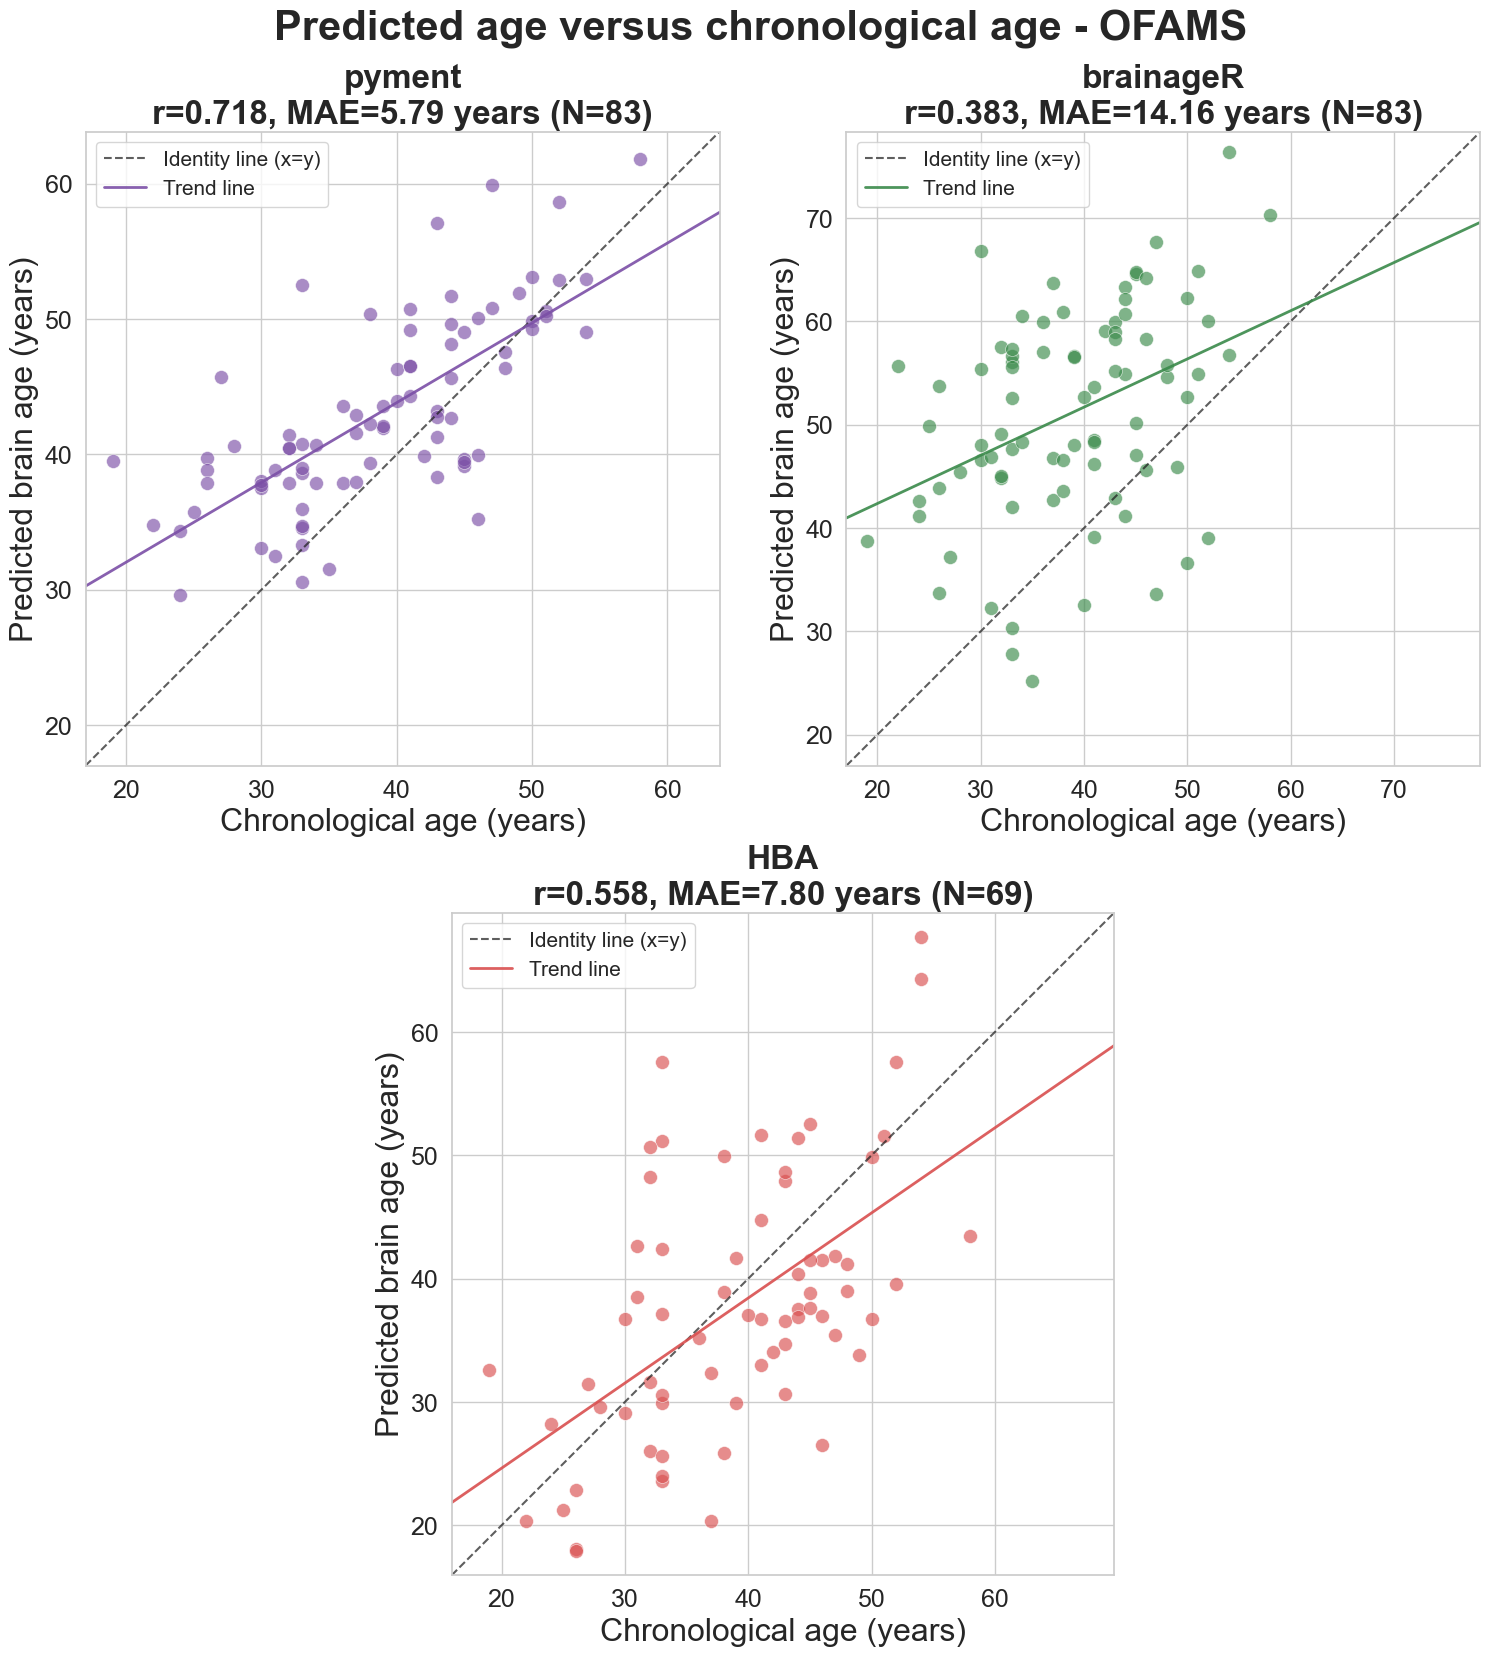

Saved: accuracy_scatter.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Opprett figuren manuelt
fig = plt.figure(figsize=(18, 18))

# Definer subplot-grid
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, (3, 4))  # nederste plott

axes = [ax1, ax2, ax3]

# Juster nederste plott: midtstilt og litt smalere
ax3.set_position([0.25, 0.05, 0.5, 0.35])

for ax, res in zip(axes, results):
    name = res['Model']
    sub = res['_df']
    color = COLORS[name]

    # Scatter
    ax.scatter(sub['age'], sub['predicted_age'],
               color=color, alpha=0.65, s=100,
               edgecolors='white', lw=0.5)

    # Identity line (x=y)
    lims = [
        min(sub['age'].min(), sub['predicted_age'].min()) - 2,
        max(sub['age'].max(), sub['predicted_age'].max()) + 2
    ]
    ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.7,
            label='Identity line (x=y)')

    # Trend line
    z = np.polyfit(sub['age'], sub['predicted_age'], 1)
    x_line = np.linspace(lims[0], lims[1], 200)
    ax.plot(x_line, np.poly1d(z)(x_line),
            color=color, lw=2, alpha=0.9,
            label='Trend line')

    # Styling
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Chronological age (years)', fontsize=23)
    ax.set_ylabel('Predicted brain age (years)', fontsize=23)

    ax.set_title(
        f'{name}\nr={res["Pearson_r"]:.3f}, MAE={res["MAE"]:.2f} years (N={res["N"]})',
        fontsize=24, fontweight='bold'
    )

    ax.legend(fontsize=15)
    ax.tick_params(axis='both', labelsize=18)
    ax.set_aspect('equal')

# Tittel
plt.suptitle('Predicted age versus chronological age - OFAMS',
             fontsize=30, fontweight='bold', y=0.98)

# Viktig: ikke bruk tight_layout her (kan ødelegge set_position)
plt.subplots_adjust(top=0.92)

# Save + show
plt.savefig('accuracy_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: accuracy_scatter.png")


> **Observations:**
>
> **Pyment** — predictions cluster closely around the identity line,
> consistent with the lower MAE and stronger correlation between predicted
> and chronological age reported in Section 2.1.
>
> **BrainageR** — the point cloud lies systematically above the identity
> line, indicating that the model overestimates age across the cohort.
> This corresponds to the elevated MAE and positive mean BAG observed for
> this model.
>
> **HBA** — predictions are more dispersed, with the point cloud falling
> predominantly below the identity line, suggesting a tendency to
> underestimate chronological age in this cohort.

## 2.3 Model Bias

### Age bias
Each panel plots BAG against chronological age at baseline. A well-calibrated
model should show no systematic relationship between BAG and age — represented
by a flat horizontal trend line.

A negative slope (high BAG in younger subjects, low BAG in older subjects)
is known as regression dilution or age bias, and is a well-documented
artefact in brain age research (de Lange & Cole, 2020). It arises because
models trained on healthy controls tend to predict ages closer to the
training mean, causing systematic overestimation in younger subjects and
underestimation in older subjects. When present, BAG is no longer
independent of chronological age, which violates the assumptions of
downstream statistical analyses.

Following de Lange & Cole (2020), age bias is addressed by including
chronological age as a covariate in all subsequent models rather than
using residualized BAG.

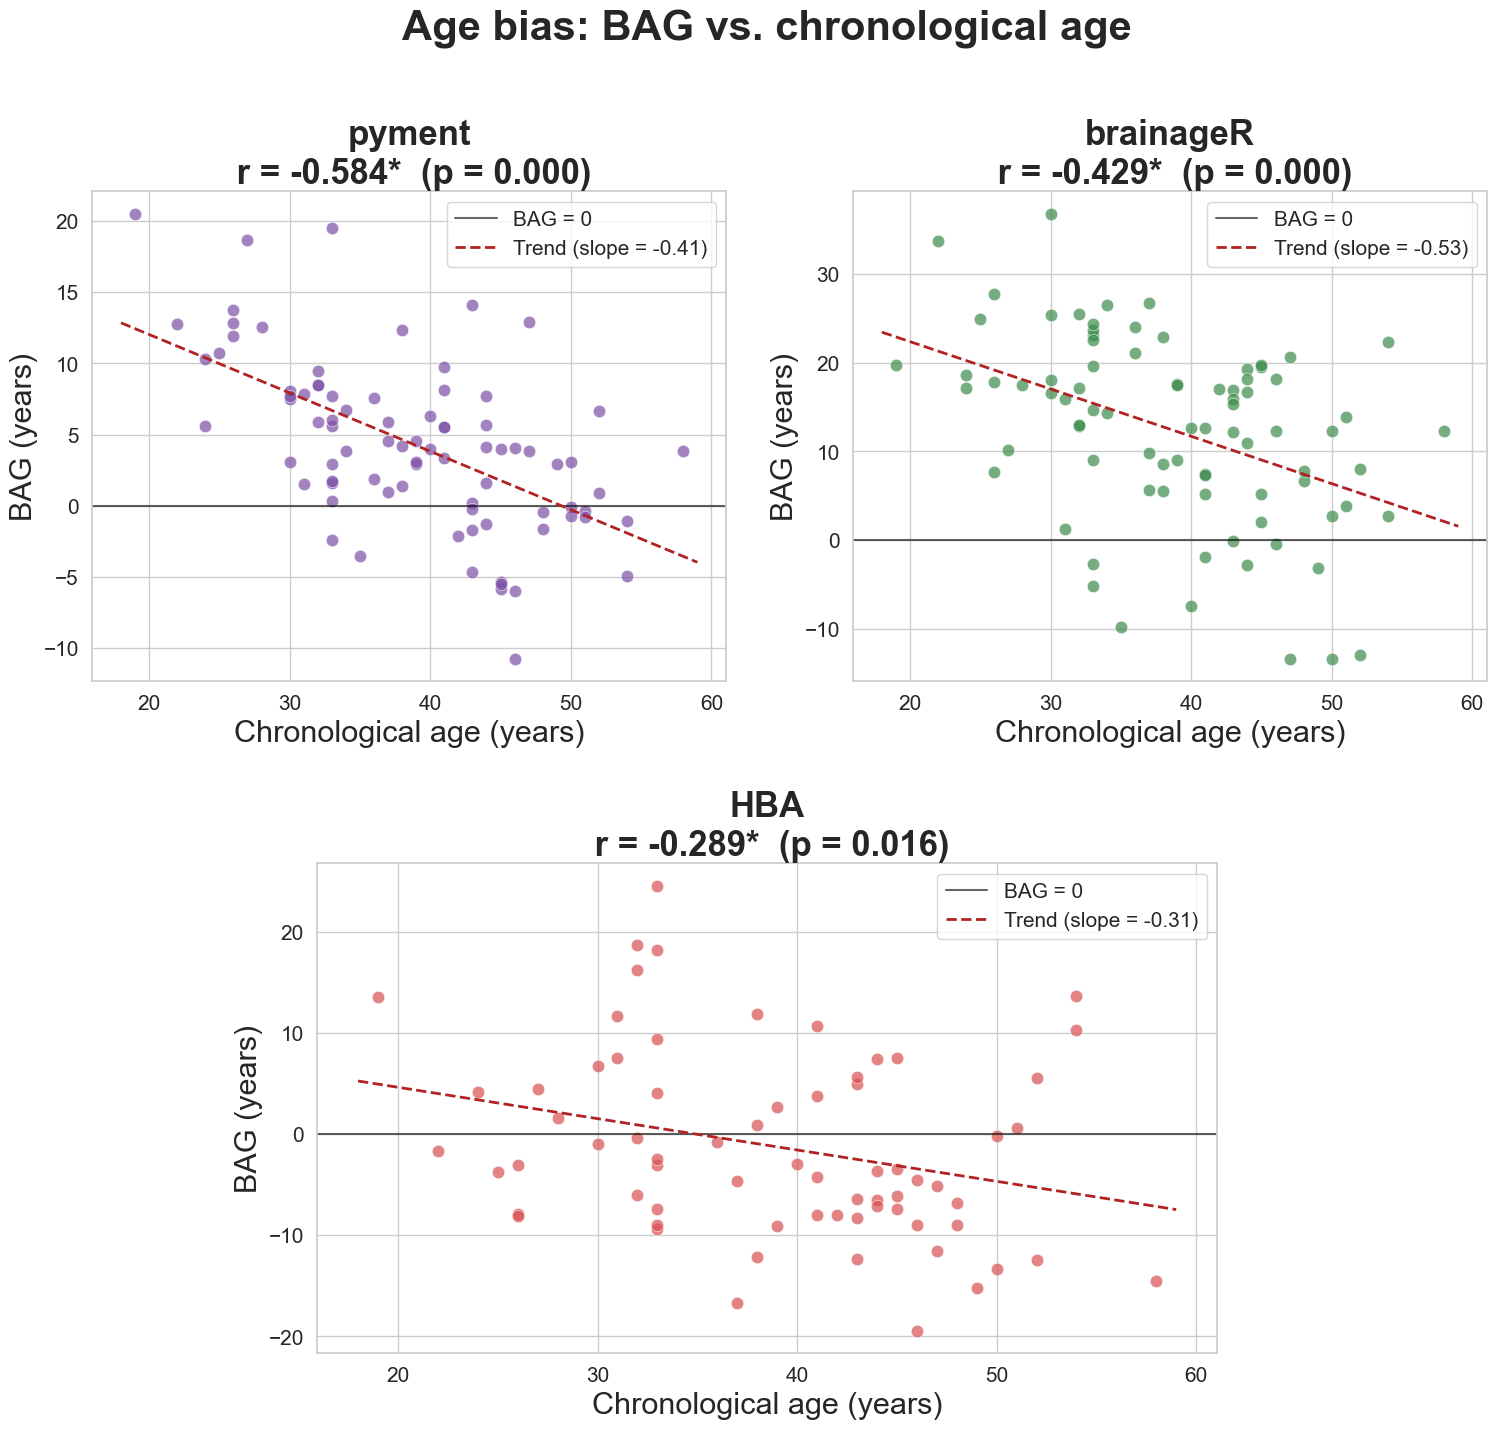

In [20]:
# Age bias: BAG vs. chronological age

# Layout: two models in the top row, one centered in the bottom row
fig = plt.figure(figsize=(18, 14))
axes = [
    fig.add_subplot(2, 2, 1),
    fig.add_subplot(2, 2, 2),
    fig.add_subplot(2, 2, (3, 4))
]
# Center the bottom panel
axes[2].set_position([0.25, 0.05, 0.5, 0.35])

fig.suptitle('Age bias: BAG vs. chronological age',
             fontsize=30, fontweight='bold', y=1.01)

for ax, res in zip(axes, results):
    name  = res['Model']
    sub   = res['_df']
    color = COLORS[name]

    # Scatter: one point per subject
    ax.scatter(sub['age'], sub['BAG'],
               color=color, alpha=0.7, s=80, edgecolors='white', lw=0.5)

    # Reference line at BAG = 0 (no brain age gap)
    ax.axhline(0, color='black', lw=1.5, linestyle='-', alpha=0.6, label='BAG = 0')

    # Linear trend line — a negative slope indicates age bias
    z = np.polyfit(sub['age'], sub['BAG'], 1)
    x_line = np.linspace(sub['age'].min() - 1, sub['age'].max() + 1, 200)
    ax.plot(x_line, np.poly1d(z)(x_line),
            color='firebrick', lw=2, linestyle='--',
            label=f'Trend (slope = {z[0]:.2f})')

    # Pearson correlation between age and BAG to quantify bias magnitude
    r_bias, p_bias = pearsonr(sub['age'], sub['BAG'])
    sig = '*' if p_bias < 0.05 else ''

    ax.set_xlabel('Chronological age (years)', fontsize=22)
    ax.set_ylabel('BAG (years)', fontsize=22)
    ax.set_title(
        f'{name}\n r = {r_bias:.3f}{sig}  (p = {p_bias:.3f})',
        fontsize=25, fontweight='bold'
    )
    ax.tick_params(axis='both', labelsize=15)
    ax.legend(fontsize=15)

plt.savefig('accuracy_age_bias.png', dpi=200, bbox_inches='tight')
plt.show()

### Scanner Effects

MRI signal characteristics vary across field strengths, which can introduce
systematic offsets in brain age predictions unrelated to true biological
ageing. If BAG differs systematically between scanners, comparisons across
subgroups may reflect hardware differences rather than disease effects.

Field strength effects (1.5 T vs. 3 T) are assessed using an independent
samples t-test on baseline BAG values. A significant result would indicate
that predictions are confounded by field strength and that scanner protocol
should be included as a covariate in subsequent analyses.

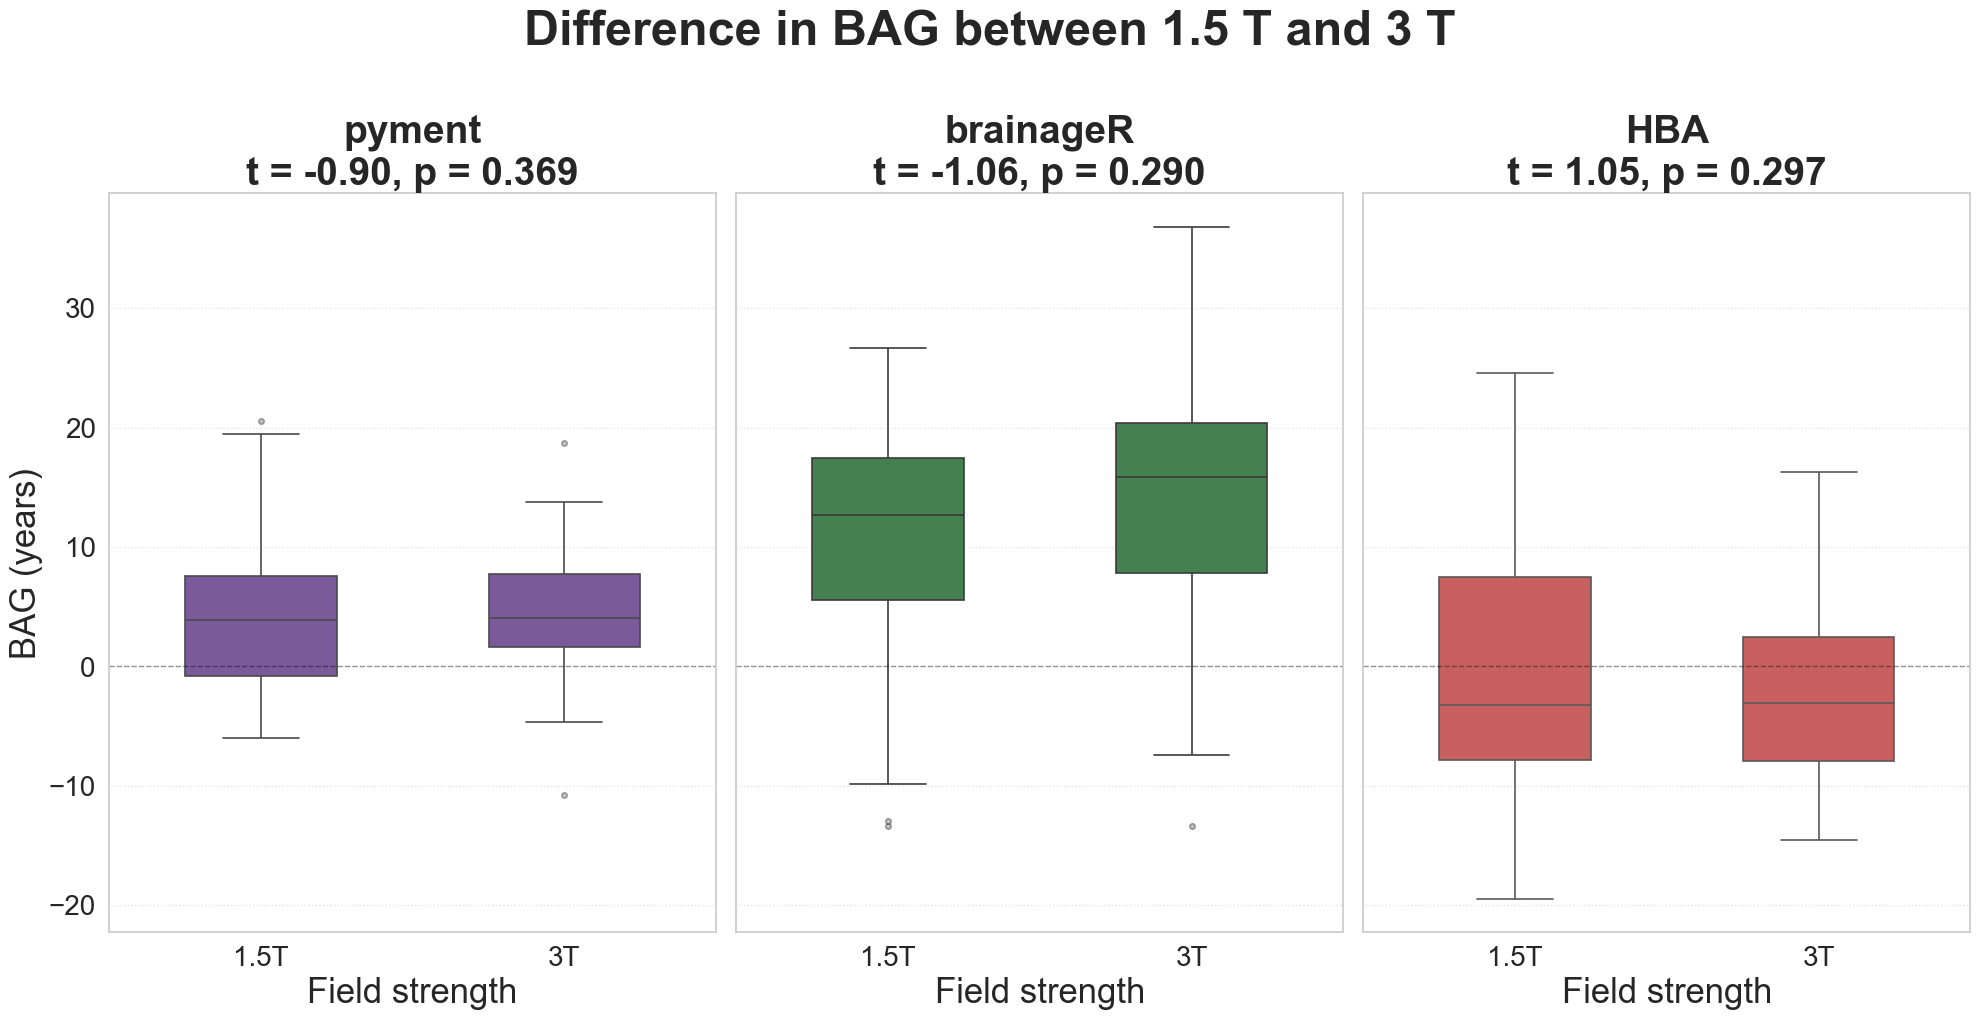

In [22]:

fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)
fig.suptitle("Difference in BAG between 1.5 T and 3 T",
             fontsize=35, fontweight="bold", y=1.02)

for ax, (name, df) in zip(axes, models.items()):

    # Separate BAG values by field strength group
    group_15 = df[df["field_strength"] == "1.5T"]["BAG"].dropna()
    group_3  = df[df["field_strength"] == "3T"]["BAG"].dropna()


    # Independent samples t-test
    t_stat, p_val = ttest_ind(group_15, group_3)

    # Convert p-value to significance stars for plot annotation
    if p_val < 0.001:
        sig = "***"
    elif p_val < 0.01:
        sig = "**"
    elif p_val < 0.05:
        sig = "*"
    else:
        sig = "ns"

    sns.boxplot(
        data=df,
        x="field_strength",
        y="BAG",
        color=COLORS[name],        # uses COLORS defined at top of notebook
        width=0.5,
        linewidth=1.2,
        flierprops=dict(marker="o", markerfacecolor="grey",
                        markersize=4, alpha=0.5, linestyle="none"),
        ax=ax
    )

    ax.axhline(0, color="black", linestyle="--", alpha=0.4, linewidth=1)
    ax.set_title(f"{name}\nt = {t_stat:.2f}, p = {p_val:.3f}",
                 fontsize=28, fontweight="bold")
    ax.set_xlabel("Field strength", fontsize=25)
    ax.set_ylabel("BAG (years)" if ax == axes[0] else "", fontsize=25)
    ax.tick_params(labelsize=20)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("field_strength_bag_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

### Sex Differences in BAG

Brain ageing trajectories may differ between males and females, and any
systematic BAG difference between sexes could confound downstream analyses
if left unaccounted for.

BAG distributions at baseline are compared between male and female subjects
using an independent samples t-test. A significant result would indicate
that sex should be included as a covariate in subsequent statistical models.

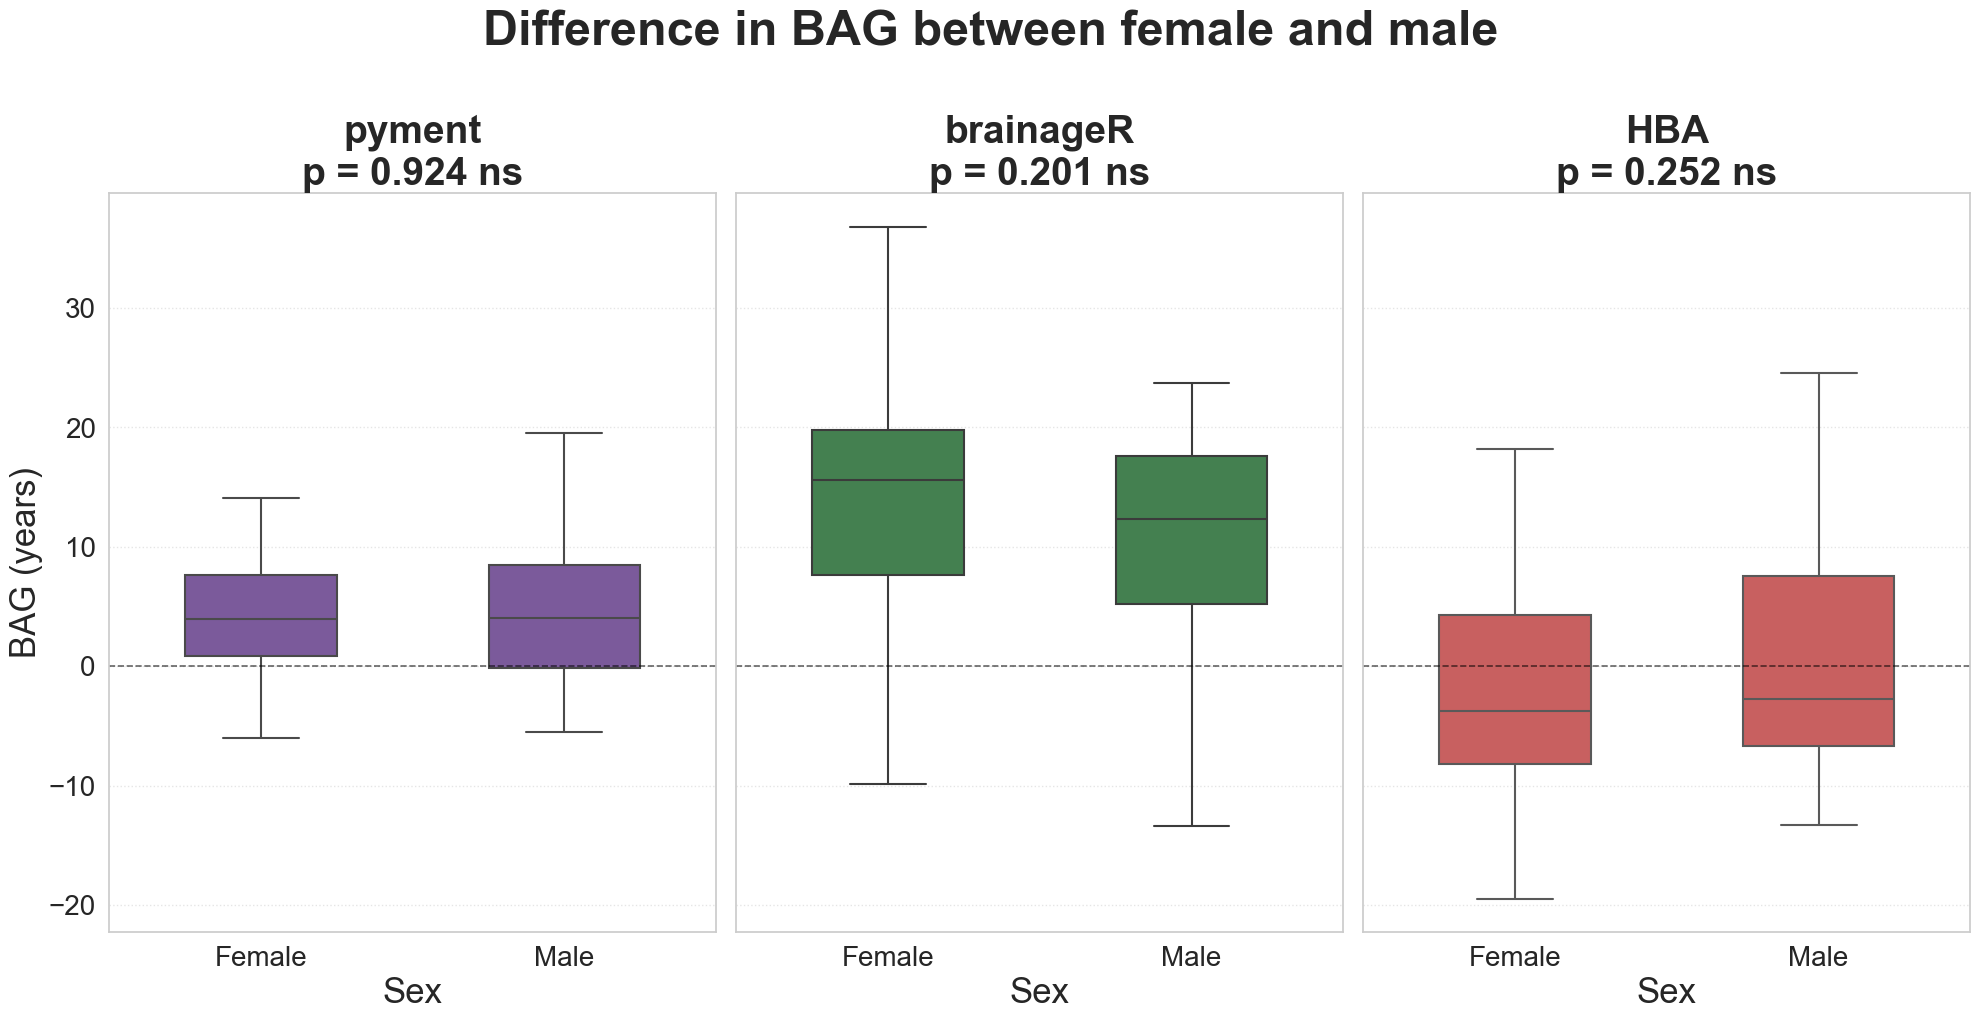

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)
fig.suptitle("Difference in BAG between female and male",
             fontsize=35, fontweight="bold", y=1.02)

for ax, (name, df) in zip(axes, models.items()):
    df = df.copy()

    # Standardize sex labels to consistent capitalized strings
    df["sex"] = df["sex"].astype(str).str.lower().replace(
        {"f": "Female", "m": "Male", "female": "Female", "male": "Male"}
    )
    df = df[df["sex"].isin(["Female", "Male"])]

    # Separate BAG by sex group
    bag_f = df.loc[df["sex"] == "Female", "BAG"].dropna()
    bag_m = df.loc[df["sex"] == "Male",   "BAG"].dropna()

     # Independent samples t-test
    _, p_val = ttest_ind(bag_f, bag_m, equal_var=False, nan_policy="omit")

    # Convert p-value to significance stars for plot annotation
    if p_val < 0.001:
        sig = "***"
    elif p_val < 0.01:
        sig = "**"
    elif p_val < 0.05:
        sig = "*"
    else:
        sig = "ns"

    sns.boxplot(data=df, x="sex", y="BAG", color=COLORS[name],
                width=0.5, fliersize=0, linewidth=1.5, ax=ax)

    # Reference line at BAG = 0 (no brain age gap)
    ax.axhline(0, color="black", lw=1.2, linestyle="--", alpha=0.6)

    ax.set_title(f"{name}\np = {p_val:.3f} {sig}", fontsize=28, fontweight="bold")
    ax.set_xlabel("Sex", fontsize=25)
    ax.set_ylabel("BAG (years)" if ax == axes[0] else "", fontsize=25)
    ax.tick_params(labelsize=20)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("bag_by_sex_before_correction.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.4 Inter-Model Correlation

If the three models capture the same underlying signal, their BAG estimates
should correlate strongly with one another. Low inter-model correlation would
suggest that the models are sensitive to different aspects of brain morphology,
and that model choice has a meaningful impact on results.

Pairwise Pearson correlations between BAG estimates are computed at baseline
and visualized as a heatmap.

### Baseline

N subjects included in correlation: 69


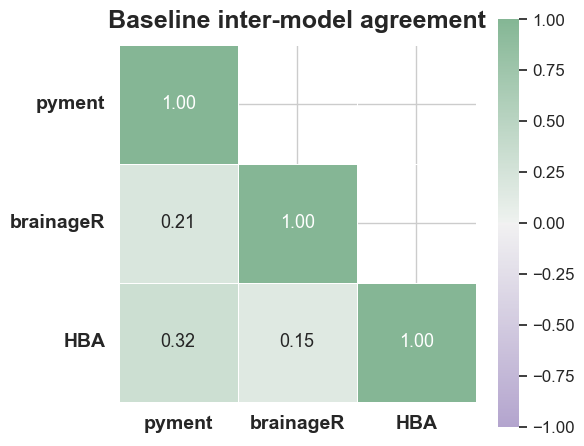

In [101]:
# Inter-model BAG correlation heatmap
# Merge BAG estimates on subject ID to ensure correct alignment across models.
# Subjects missing from one or more models are excluded (inner join).
corr_df = (
    bl_pyment[["subject", "BAG"]].rename(columns={"BAG": "pyment"})
    .merge(bl_bar[["subject", "BAG"]].rename(columns={"BAG": "brainageR"}),
           on="subject", how="inner")
    .merge(bl_hba[["subject", "BAG"]].rename(columns={"BAG": "HBA"}),
           on="subject", how="inner")
)
print(f"N subjects included in correlation: {len(corr_df)}")

# Compute pairwise Pearson correlation matrix
matrix = corr_df[["pyment", "brainageR", "HBA"]].corr()

# Mask the upper triangle to avoid displaying redundant values
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)

# Diverging colormap derived from model palette (purple → green)
cmap = sns.diverging_palette(280, 140, s=40, l=70, as_cmap=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 13},
    square=True,
    ax=ax
)
ax.set_title("Baseline inter-model agreement",
             fontsize=18, fontweight="bold", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14, fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight="bold", rotation=0)
plt.tight_layout()
plt.savefig("bag_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Longitudinal

In [105]:
# ── Inter-model agreement across all timepoints (LME) ────────────────────────
# Two model specifications per pair:
#   Unadjusted: BA_outcome ~ BA_predictor + (1|subject)
#   Adjusted:   BA_outcome ~ BA_predictor + age + sex + disease_duration + (1|subject)
# Bonferroni correction applied within each specification (m=3 pairs)

from statsmodels.stats.multitest import multipletests

# Merge predicted age from all three models on subject and session
lme_df = (
    pyment[["subject", "session", "predicted_age", "age", "sex", "DISEASE_DURATION"]]
    .rename(columns={"predicted_age": "BA_pyment"})
    .merge(
        bar[["subject", "session", "predicted_age"]]
        .rename(columns={"predicted_age": "BA_brainageR"}),
        on=["subject", "session"], how="inner"
    )
    .merge(
        hba[["subject", "session", "predicted_age"]]
        .rename(columns={"predicted_age": "BA_HBA"}),
        on=["subject", "session"], how="inner"
    )
)

print(f"N observations: {len(lme_df)}")
print(f"N subjects:     {lme_df['subject'].nunique()}")

pairs = [
    ("BA_pyment",    "BA_brainageR"),
    ("BA_pyment",    "BA_HBA"),
    ("BA_brainageR", "BA_HBA"),
]

# Collect p-values for Bonferroni correction
results_unadj = []
results_adj   = []

for x_var, y_var in pairs:

    # Unadjusted
    sub = lme_df[[x_var, y_var, "subject"]].dropna()
    model_unadj = smf.mixedlm(
        f"{y_var} ~ {x_var}",
        data=sub,
        groups=sub["subject"]
    ).fit(reml=True)
    results_unadj.append({
        "pair":  f"{x_var} → {y_var}",
        "slope": model_unadj.params[x_var],
        "p":     model_unadj.pvalues[x_var]
    })

    # Adjusted
    sub_adj = lme_df[[x_var, y_var, "subject", "age", "sex", "DISEASE_DURATION"]].dropna()
    model_adj = smf.mixedlm(
        f"{y_var} ~ {x_var} + age + C(sex) + DISEASE_DURATION",
        data=sub_adj,
        groups=sub_adj["subject"]
    ).fit(reml=True)
    results_adj.append({
        "pair":  f"{x_var} → {y_var}",
        "slope": model_adj.params[x_var],
        "p":     model_adj.pvalues[x_var]
    })

# Apply Bonferroni correction within each specification (m=3)
for label, results in [("Unadjusted", results_unadj), ("Adjusted", results_adj)]:
    p_vals = [r["p"] for r in results]
    reject, p_corrected, _, alpha_corrected = multipletests(
        p_vals, alpha=0.05, method="bonferroni"
    )
    print(f"\nInter-model agreement — {label}")
    print(f"Bonferroni-corrected α = {alpha_corrected:.4f}")
    print("=" * 65)
    for r, p_corr, sig in zip(results, p_corrected, reject):
        star = "*" if sig else "ns"
        print(f"  {r['pair']}")
        print(f"  slope = {r['slope']:.3f}  p = {r['p']:.4f}  "
              f"p_corrected = {p_corr:.4f}  {star}")

N observations: 311
N subjects:     87

Inter-model agreement — Unadjusted
Bonferroni-corrected α = 0.0167
  BA_pyment → BA_brainageR
  slope = 0.078  p = 0.3242  p_corrected = 0.9725  ns
  BA_pyment → BA_HBA
  slope = 0.223  p = 0.0052  p_corrected = 0.0156  *
  BA_brainageR → BA_HBA
  slope = 0.147  p = 0.0119  p_corrected = 0.0356  *

Inter-model agreement — Adjusted
Bonferroni-corrected α = 0.0167
  BA_pyment → BA_brainageR
  slope = 0.381  p = 0.0002  p_corrected = 0.0005  *
  BA_pyment → BA_HBA
  slope = 0.055  p = 0.5952  p_corrected = 1.0000  ns
  BA_brainageR → BA_HBA
  slope = 0.180  p = 0.0011  p_corrected = 0.0032  *


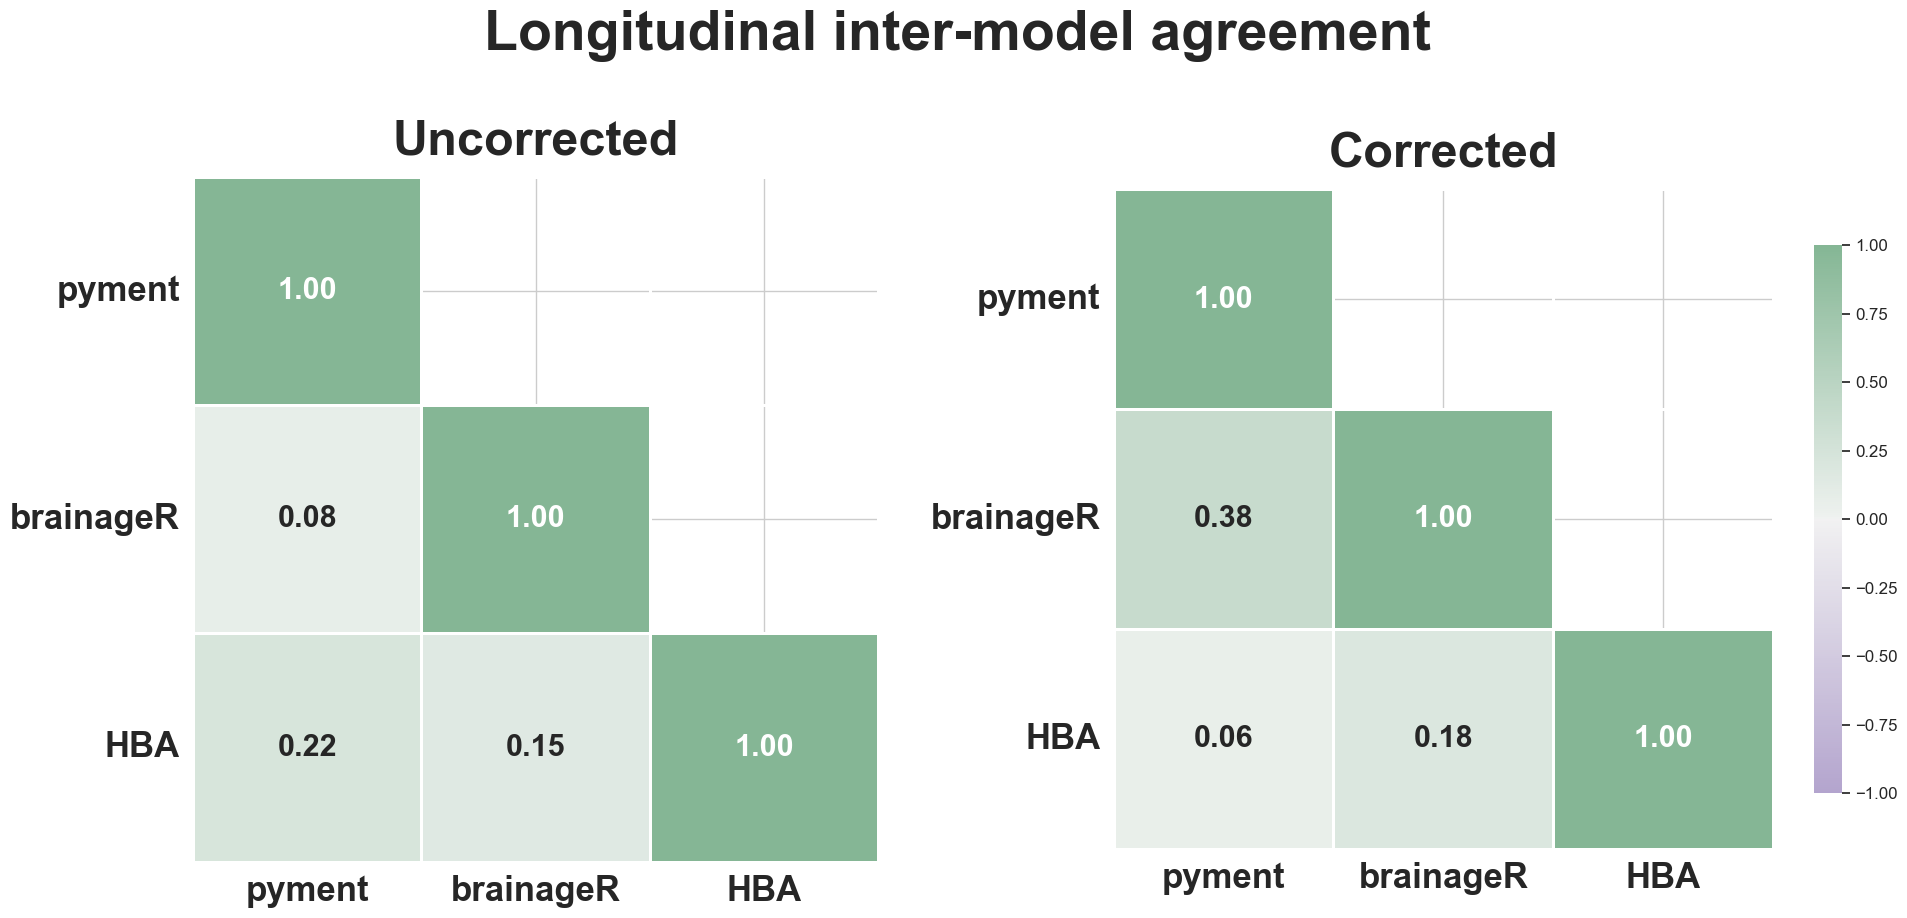

In [103]:
# ── Inter-model agreement heatmap: unadjusted vs. adjusted (LME) ─────────────

models_order = ["pyment", "brainageR", "HBA"]

unadj_matrix = pd.DataFrame(
    data=[
        [1.000, 0.078, 0.223],
        [0.078, 1.000, 0.147],
        [0.223, 0.147, 1.000],
    ],
    index=models_order,
    columns=models_order
)

adj_matrix = pd.DataFrame(
    data=[
        [1.000, 0.381, 0.055],
        [0.381, 1.000, 0.180],
        [0.055, 0.180, 1.000],
    ],
    index=models_order,
    columns=models_order
)

mask = np.triu(np.ones((3, 3), dtype=bool), k=1)
cmap = sns.diverging_palette(280, 140, s=40, l=70, as_cmap=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.subplots_adjust(wspace=0.02)

for ax, matrix, title in zip(
    axes,
    [unadj_matrix, adj_matrix],
    ["Uncorrected", "Corrected"]
):
    sns.heatmap(
        matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        vmin=-1, vmax=1,
        linewidths=0.8,
        linecolor="white",
        annot_kws={"size": 22, "weight": "bold"},
        square=True,
        ax=ax,
        cbar=ax == axes[1],
        cbar_kws={"shrink": 0.8}
    )
    ax.set_title(title, fontsize=35, fontweight="bold", pad=16)

    # Bold and large model name labels
    ax.set_xticklabels(
        ax.get_xticklabels(),
        fontsize=25,
        fontweight="bold"
    )
    ax.set_yticklabels(
        ax.get_yticklabels(),
        fontsize=25,
        fontweight="bold",
        rotation=0
    )

fig.suptitle(
    "Longitudinal inter-model agreement",
    fontsize=40, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("bag_lme_slope_heatmap_longitudinal.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.5 Test-Retest Reliability

Brain age models intended for longitudinal use should produce consistent
predictions when applied to scans acquired close in time under identical
or near-identical conditions. Test-retest reliability quantifies this
consistency: a reliable model should assign similar brain age estimates
to the same subject at two timepoints where no true biological change is
expected.

Reliability is assessed using the Intraclass Correlation Coefficient (ICC),
which measures the proportion of total variance attributable to between-subject
differences rather than measurement noise. ICC values are interpreted following
Koo & Mae (2016): ICC < 0.50 poor, 0.50–0.75 moderate, 0.75–0.90 good,
and > 0.90 excellent reliability.

In the OFAMS cohort, several subjects were scanned at consecutive monthly
timepoints (m1–m9), providing a natural test-retest sample. Pairs of
adjacent timepoints are used to compute ICC for each model.

In [33]:
hba["session"].unique()

array(['m6', 'm24', 'm120', 'baseline', 'm3', 'm5', 'm8', 'm9', 'm2',
       'm7', 'm12', 'm1', 'm4'], dtype=object)

In [34]:
hba['session'].value_counts().sort_index()


session
baseline    69
m1           8
m12          3
m120        69
m2           5
m24         66
m3           3
m4           1
m5          11
m6          70
m7           5
m8           3
m9           3
Name: count, dtype: int64

In [35]:
# Test-retest reliability: baseline vs. m1

def run_reliability_analysis(df, model_name, val_col="predicted_age"):
    """
    Assess test-retest reliability between baseline and m1 for one model.

    Computes Pearson correlation and ICC2 (two-way random effects, single
    measures) between predicted age at baseline and m1. ICC2 is appropriate
    here as subjects are treated as random effects and the two sessions are
    the raters.

    Parameters
    ----------
    df : DataFrame
        Full longitudinal dataframe for one model.
    model_name : str
        Model name used for printed output.
    val_col : str
        Column containing predicted age values (default: 'predicted_age').

    Returns
    -------
    wide : DataFrame
        Pivoted dataframe with one column per session (baseline, m1).
    icc_results : DataFrame
        Full ICC results table from pingouin.
    """
    # Subset to baseline and m1 timepoints
    tmp = df[df["session"].isin(["baseline", "m1"])].copy()

    # Pivot to wide format: one row per subject, one column per session
    wide = tmp.pivot(index="subject", columns="session",
                     values=val_col).dropna()

    # Pearson correlation between the two timepoints
    r, p = pearsonr(wide["baseline"], wide["m1"])

    # ICC requires long format: subject | session | score
    long_format = (wide.reset_index()
                       .melt(id_vars="subject", value_name="score"))

    icc_results = pg.intraclass_corr(
        data=long_format,
        targets="subject",
        raters="session",
        ratings="score"
    )

    # Extract ICC2 (two-way random effects, single measures)
    icc_val = icc_results.set_index('Type').loc['ICC2', 'ICC']
    icc_ci  = icc_results.set_index('Type').loc['ICC2', 'CI95']

    print(f"--- {model_name} reliability (N={len(wide)}) ---")
    print(f"Pearson r: {r:.3f}  (p = {p:.1e})")
    print(f"ICC2:      {icc_val:.3f}  [95% CI: {icc_ci}]")
    print("-" * 40)

    return wide, icc_results


# ── Run reliability analysis for all three models ─────────────────────────────
py_wide,  py_icc  = run_reliability_analysis(pyment, "Pyment")
br_wide,  br_icc  = run_reliability_analysis(bar,    "BrainageR")
hba_wide, hba_icc = run_reliability_analysis(hba,    "HBA")

--- Pyment reliability (N=80) ---
Pearson r: 0.914  (p = 2.8e-32)
ICC2:      0.912  [95% CI: [0.87 0.94]]
----------------------------------------
--- BrainageR reliability (N=80) ---
Pearson r: 0.923  (p = 5.2e-34)
ICC2:      0.921  [95% CI: [0.88 0.95]]
----------------------------------------
--- HBA reliability (N=6) ---
Pearson r: 0.875  (p = 2.3e-02)
ICC2:      0.891  [95% CI: [0.41 0.98]]
----------------------------------------


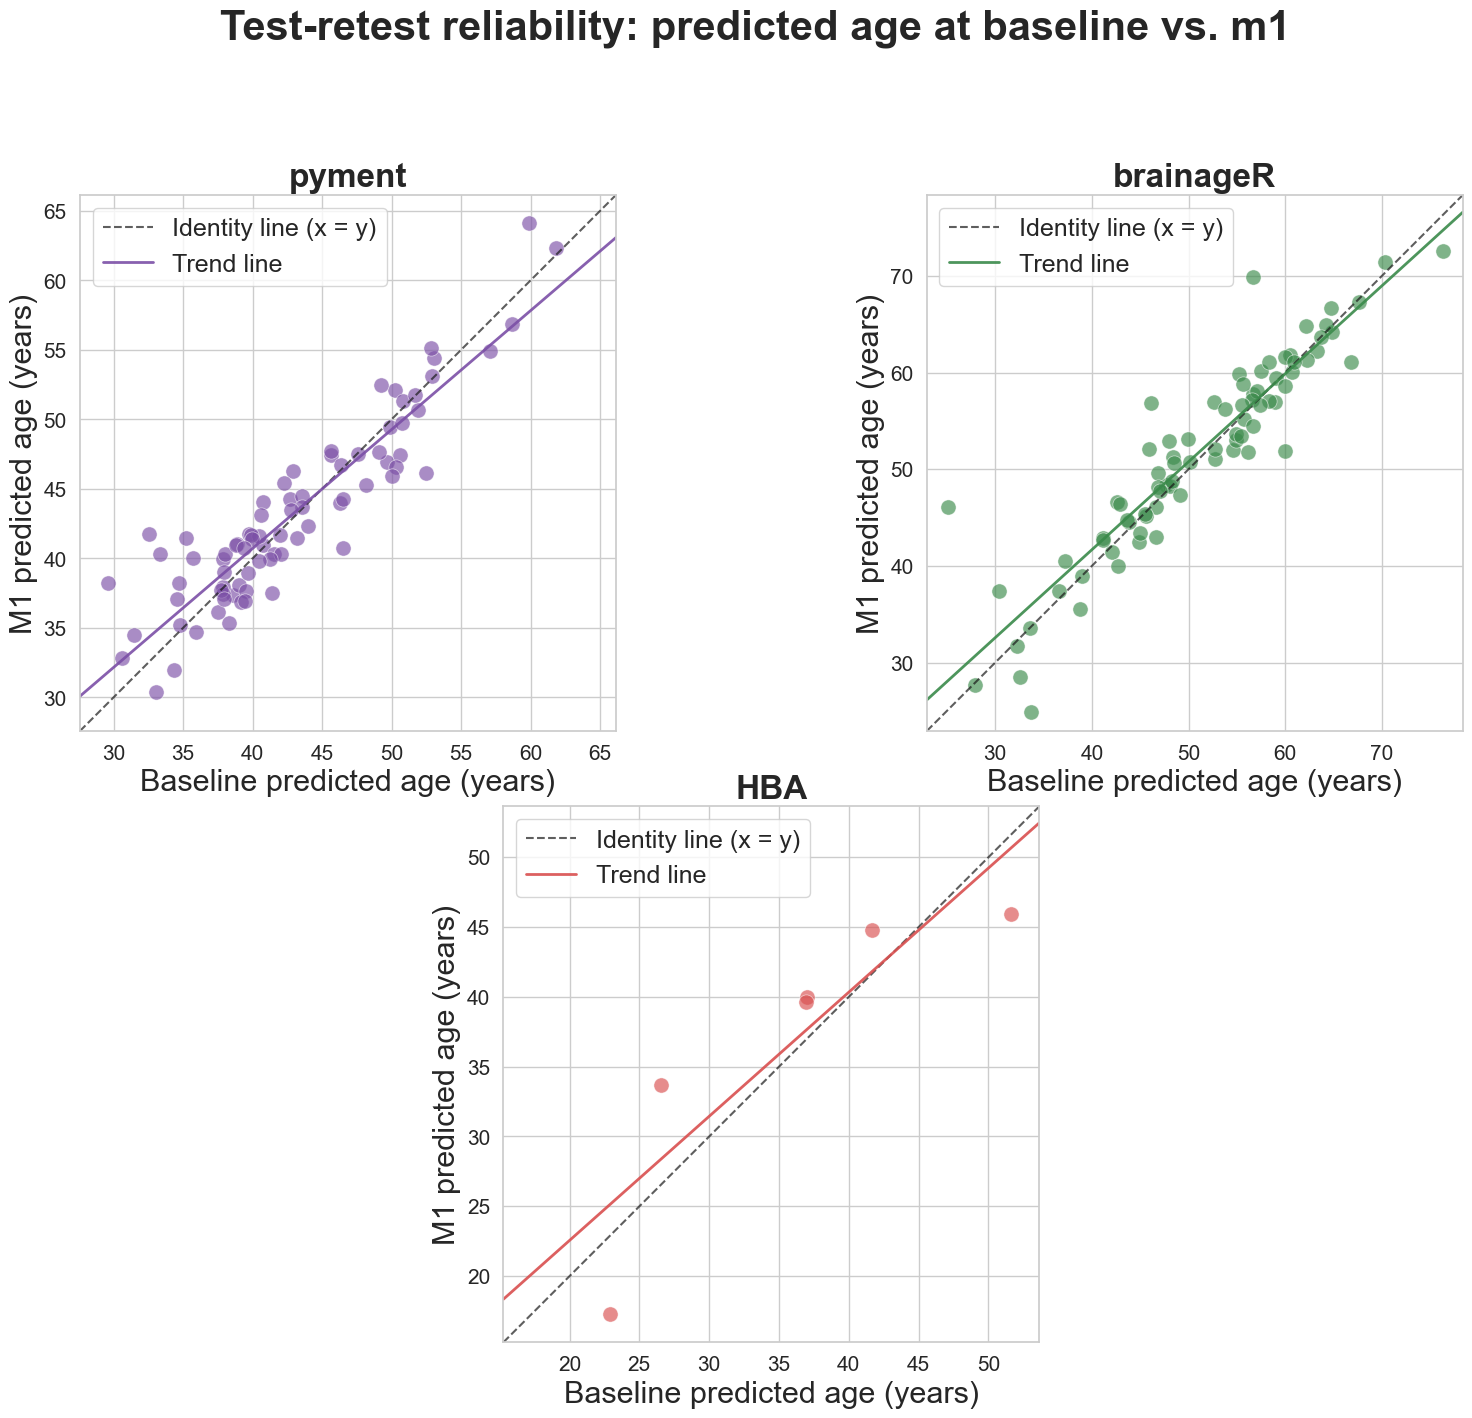

Saved: test_retest_scatter.png


In [36]:
# Test-retest scatter plot: baseline vs. m1

fig = plt.figure(figsize=(18, 16))

# Two models in top row, one centered in bottom row
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, (3, 4))
axes = [ax1, ax2, ax3]

# Center the bottom panel
ax3.set_position([0.25, 0.05, 0.5, 0.35])

plot_data = [
    ("pyment",    py_wide),
    ("brainageR", br_wide),
    ("HBA",       hba_wide)
]

for ax, (name, df) in zip(axes, plot_data):
    color = COLORS[name]

    # Scatter: one point per subject
    ax.scatter(df['baseline'], df['m1'],
               color=color, alpha=0.65, s=120, edgecolors='white', lw=0.5)

    # Axis limits with padding
    lims = [
        min(df['baseline'].min(), df['m1'].min()) - 2,
        max(df['baseline'].max(), df['m1'].max()) + 2
    ]

    # Identity line: perfect test-retest would fall exactly on this line
    ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.7, label='Identity line (x = y)')

    # Linear trend line fitted to the data
    mask = ~np.isnan(df['baseline']) & ~np.isnan(df['m1'])
    z = np.polyfit(df['baseline'][mask], df['m1'][mask], 1)
    x_line = np.linspace(lims[0], lims[1], 200)
    ax.plot(x_line, np.poly1d(z)(x_line),
            color=color, lw=2, alpha=0.9, label='Trend line')

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(f"{name}", fontsize=24, fontweight='bold')
    ax.set_xlabel("Baseline predicted age (years)", fontsize=22)
    ax.set_ylabel("M1 predicted age (years)", fontsize=22)
    ax.legend(fontsize=18)
    ax.tick_params(axis='both', labelsize=15)

plt.suptitle("Test-retest reliability: predicted age at baseline vs. m1",
             fontsize=30, fontweight='bold', y=0.98)
plt.tight_layout(pad=4.0)
plt.savefig("test_retest_scatter.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: test_retest_scatter.png")

In [37]:
# Test-retest reliability across long-term timepoints

models = {
    "pyment":    pyment,
    "brainageR": bar,
    "HBA":       hba,
}

# Timepoints used for longitudinal reliability assessment
sessions = ("baseline", "m6", "m24", "m120")


def prepare_long_icc_data(df, value_col, subject_col, session_col,
                           sessions, min_measurements=2):
    """
    Subset and filter a longitudinal dataframe for ICC analysis.

    Retains only rows from the specified sessions, drops missing values,
    and excludes subjects with fewer than min_measurements observations.

    Parameters
    ----------
    df : DataFrame
        Full longitudinal dataframe for one model.
    value_col : str
        Column containing the predicted age values.
    subject_col : str
        Column identifying subjects.
    session_col : str
        Column identifying sessions.
    sessions : tuple of str
        Session labels to include.
    min_measurements : int
        Minimum number of valid observations required per subject.

    Returns
    -------
    DataFrame
        Filtered long-format dataframe ready for ICC computation.
    """
    d = df[[subject_col, session_col, value_col]].copy()
    d = d[d[session_col].isin(sessions)].dropna(subset=[value_col])

    # Exclude subjects with too few timepoints for reliable ICC estimation
    counts = d.groupby(subject_col)[value_col].count()
    valid  = counts[counts >= min_measurements].index

    return d[d[subject_col].isin(valid)].copy()


# Run reliability analysis per model 
results = []

for name, df in models.items():

    # Prepare filtered long-format data
    d = prepare_long_icc_data(
        df=df,
        value_col="predicted_age",
        subject_col="subject",
        session_col="session",
        sessions=sessions,
        min_measurements=2
    )

    n_subjects     = d["subject"].nunique()
    n_images       = len(d)
    session_counts = (d["session"].value_counts()
                                  .reindex(sessions)
                                  .fillna(0)
                                  .astype(int))
    
    # Check sufficient data before running ICC
    if len(d) < 5:
        print(f"\n── {name}: insufficient data for ICC (N={len(d)}) ──")
        continue

    # Check that at least two sessions are represented
    if d["session"].nunique() < 2:
        print(f"\n── {name}: fewer than 2 sessions available, skipping ICC ──")
        continue

   
    # ICC2: two-way random effects, single measures.
    # Appropriate for unbalanced repeated-measures data when both subjects
    # and sessions are treated as random effects.
    icc_table = pg.intraclass_corr(
        data=d,
        targets="subject",
        raters="session",
        ratings="predicted_age",
        nan_policy="omit"
    )
    icc2_row = icc_table[icc_table["Type"] == "ICC2"].iloc[0]
    icc2     = icc2_row["ICC"]
    icc2_ci  = icc2_row["CI95"]

    # Pearson correlation: baseline vs. each subsequent timepoint.
    # Captures how consistency degrades over longer follow-up intervals.
    wide = d.pivot_table(index="subject", columns="session",
                         values="predicted_age")
    pearson_results = {}
    for ses in sessions[1:]:
        if ses in wide.columns and "baseline" in wide.columns:
            pair = wide[["baseline", ses]].dropna()
            if len(pair) >= 5:
                r, p = stats.pearsonr(pair["baseline"], pair[ses])
                pearson_results[ses] = (len(pair), round(r, 3), round(p, 4))
            else:
                pearson_results[ses] = (len(pair), None, None)

    # Print summary
    print(f"\n── {name} (sessions: {', '.join(sessions)}) ──")
    print(f"N subjects: {n_subjects}  |  N observations: {n_images}")
    print("Observations per session:")
    for ses, cnt in session_counts.items():
        print(f"  {ses}: {cnt}")
    print(f"\nICC2: {icc2:.3f}  (95% CI: {icc2_ci[0]:.3f}–{icc2_ci[1]:.3f})")
    print("\nPearson r (baseline vs. each timepoint):")
    for ses, vals in pearson_results.items():
        n, r, p = vals
        if r is not None:
            print(f"  baseline vs. {ses}: r = {r:.3f}, p = {p:.4f}, N = {n}")
        else:
            print(f"  baseline vs. {ses}: insufficient data (N = {n})")

    results.append({
        "model":      name,
        "n_subjects": n_subjects,
        "n_images":   n_images,
        "ICC2":       round(icc2, 3),
        "ICC2_CI_lo": round(icc2_ci[0], 3),
        "ICC2_CI_hi": round(icc2_ci[1], 3),
        **{f"r_baseline_vs_{ses}": pearson_results.get(ses, (None, None, None))[1]
           for ses in sessions[1:]}
    })

# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
print("\n── Summary ──────────────────────────────────────────")
print(results_df.to_string(index=False))


── pyment (sessions: baseline, m6, m24, m120) ──
N subjects: 87  |  N observations: 318
Observations per session:
  baseline: 83
  m6: 86
  m24: 78
  m120: 71

ICC2: 0.549  (95% CI: 0.310–0.720)

Pearson r (baseline vs. each timepoint):
  baseline vs. m6: r = 0.833, p = 0.0000, N = 82
  baseline vs. m24: r = 0.853, p = 0.0000, N = 74
  baseline vs. m120: r = 0.583, p = 0.0000, N = 68

── brainageR (sessions: baseline, m6, m24, m120) ──
N subjects: 87  |  N observations: 314
Observations per session:
  baseline: 83
  m6: 86
  m24: 78
  m120: 67

ICC2: 0.531  (95% CI: 0.390–0.670)

Pearson r (baseline vs. each timepoint):
  baseline vs. m6: r = 0.892, p = 0.0000, N = 82
  baseline vs. m24: r = 0.781, p = 0.0000, N = 74
  baseline vs. m120: r = 0.421, p = 0.0005, N = 65

── HBA (sessions: baseline, m6, m24, m120) ──
N subjects: 82  |  N observations: 270
Observations per session:
  baseline: 68
  m6: 70
  m24: 65
  m120: 67

ICC2: 0.492  (95% CI: 0.330–0.660)

Pearson r (baseline vs. eac